## Introduction to Quantum Computing: Labs

### Solution for Lab 6: Grover on Quantum Hardware

In this lab, we will use a real quantum computer for the first time.
As an example, we will use the Grover algorithm from the previous lab and run it on a free system from **IBM Quantum**.

To execute a quantum circuit on the IBM Quantum Cloud, you need an account.
You can register for free at <https://quantum.cloud.ibm.com/signin> and receive 10 minutes of free computing time.

If you do not wish to create your own account, please contact me. I can provide you with an access token for the IBM Quantum Cloud for this lab session.

### Exercise 1: Implementing the Grover Algorithm

As a first exercise, we will write two Python functions that generate a circuit for the Grover algorithm.
The number of qubits and the number of Grover steps should be freely selectable.

We follow the example from the last lab and search for the state where all qubits are in the $\ket{1}$ state.

We will adopt the routines for creating the equal superposition (`initial_state`) and for amplitude amplification (`amplitude_amplification`) unchanged from the previous lab.
As before, these components can be combined using the `compose` function.

In this task, two variants of the oracle are to be implemented:
- A version without an ancilla qubit
- A version with an ancilla qubit

For both approaches, we again need the multi-controlled X-gate (`mcx`) in the oracle.
We will omit the final measurements at this point for now.

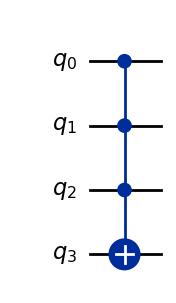

In [1]:
from qiskit import QuantumCircuit

quantum_circuit = QuantumCircuit(4)
quantum_circuit.mcx([0, 1, 2], 3)
quantum_circuit.draw("mpl")

In [2]:
# Example for the compose function
quantum_circuit1 = QuantumCircuit(1)
quantum_circuit2 = QuantumCircuit(1)
quantum_circuit1.compose(quantum_circuit2, inplace=True)

**Exercise 1.1:** Implementation of the Grover algorithm *without* ancilla qubits for an arbitrary number of qubits and Grover steps.

Use the existing routines for the initial state and for amplitude amplification.
The oracle without an additional ancilla qubit can be implemented using a multi-controlled Z-gate.
Since such a gate does not exist directly in Qiskit, we use the following trick: $Z = H X H$

By embedding the multi-controlled X-gate between two Hadamard gates on the target qubit, a controlled Z-gate can be realized.

The available building blocks to implement the Grover algorithm are:
 - ``initial_state(num_data_qubits)``: Implementation of the equal superposition state.
 - ``amplitude_amplification(num_data_qubits)``: Implementation of the amplitude amplification. 

The implementation of the oracle is up to you. 

In [3]:
from qc_lecture_tools.grover import initial_state
from qc_lecture_tools.grover import amplitude_amplification
from qc_lecture_tools.grover import print_grover_states

In [4]:
def grover(num_data_qubits: int, num_steps: int) -> QuantumCircuit:
    """Implementation of the Grover algorithm that finds the |1...11> state

    Args:
        num_data_qubits (int): Number of data qubits
        num_steps (int): Number of Grover steps

    Returns:
        QuantumCircuit: Quantum circuit of the Grover algorithm
    """

    # Create a quantum circuit with the given number of data qubits
    quantum_circuit = QuantumCircuit(num_data_qubits)

    # Prepare the initial uniform superposition (usually |s⟩ state)
    quantum_circuit.compose(initial_state(num_data_qubits, 0), inplace=True)

    # Define the control qubits (all except the last qubit, which acts as target)
    control_qubits = list(range(num_data_qubits - 1))

    # Repeat the Grover iteration (oracle + amplitude amplification)
    for i in range(num_steps):

        # --- Oracle step ---
        # The oracle marks the "solution" state by flipping its phase.
        # Here represented by a controlled multi-qubit X (inversion) gate.
        quantum_circuit.h(num_data_qubits - 1)
        quantum_circuit.mcx(control_qubits, num_data_qubits - 1)
        quantum_circuit.h(num_data_qubits - 1)

        # --- Diffusion (Amplitude amplification) step ---
        # Reflects the state vector about the average amplitude.
        quantum_circuit.compose(
            amplitude_amplification(num_data_qubits, 0), inplace=True
        )

    # Return the constructed Grover circuit
    return quantum_circuit

You can visualize the generated quantum circuit with the following code:

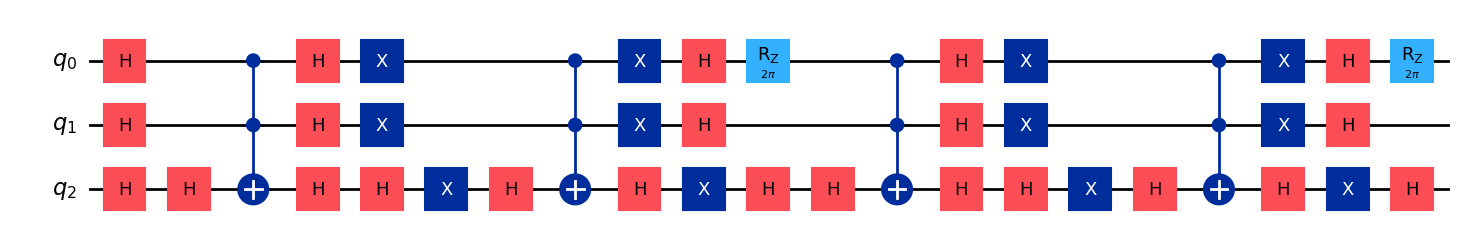

In [5]:
num_data_qubits = 3
num_steps = 2

quantum_circuit = grover(num_data_qubits, num_steps)
quantum_circuit.draw("mpl")

Test if your implementation delivers the expected result:
We use the function ``print_grover_states(quantum_circuit, num_data_qubits)`` again here to output the resulting quantum state.

In [6]:
num_data_qubits = 3
num_steps = 2

quantum_circuit = grover(num_data_qubits, num_steps)
print_grover_states(quantum_circuit, num_data_qubits)

Found basis states with non-zero amplitudes:
000: -0.09  Probability:  0.01
001: -0.09  Probability:  0.01
010: -0.09  Probability:  0.01
011: -0.09  Probability:  0.01
100: -0.09  Probability:  0.01
101: -0.09  Probability:  0.01
110: -0.09  Probability:  0.01
111:  0.97  Probability:  0.95


**Exercise 1.2:** Now implement the Grover algorithm with an additional ancilla qubit using the Compute-Uncompute approach. 

In this approach, we use an ancilla qubit to temporarily store whether all data qubits are in the $\ket{1}$ state (Compute step).
Then, the sign of the amplitude of this state is changed using a Z-gate.
Finally, in the Uncompute step, the ancilla qubit is returned to the $\ket{0}$ state so that no additional entanglement remains in the system.


In [7]:
def grover_ancilla(num_data_qubits, num_steps):
    """Implementation of the Grover algorithm that finds the |1...11> state using an Ancilla-Qubit

    Args:
        num_data_qubits (int): Number of data qubits
        num_steps (int): Number of Grover steps

    Returns:
        QuantumCircuit: Quantum circuit of the Grover algorithm with ancilla
    """

    # Create a quantum circuit with one extra ancilla qubit
    quantum_circuit = QuantumCircuit(num_data_qubits + 1)

    # Prepare the initial state, e.g., uniform superposition of all data qubits
    # and the ancilla initialized to |1⟩ (controlled oracle requires ancilla)
    quantum_circuit.compose(initial_state(num_data_qubits, 1), inplace=True)

    # Define the control qubits (all data qubits)
    control_qubits = list(range(num_data_qubits))

    # Perform the specified number of Grover iterations
    for i in range(num_steps):

        # --- Oracle step ---
        # Flip the phase of the |11...1> state using the ancilla qubit.
        # The sequence mcx -> z -> mcx implements a conditional phase inversion.
        quantum_circuit.mcx(control_qubits, num_data_qubits)  # Controlled-X on ancilla
        quantum_circuit.z(num_data_qubits)  # Phase flip on ancilla
        quantum_circuit.mcx(control_qubits, num_data_qubits)  # Undo the controlled-X

        # --- Diffusion (Amplitude amplification) step ---
        # Reflects the state about the mean amplitude to amplify the marked state.
        quantum_circuit.compose(
            amplitude_amplification(num_data_qubits, 1), inplace=True
        )

    # Return the constructed Grover circuit with ancilla
    return quantum_circuit

You can visualize the generated quantum circuit with the following code:


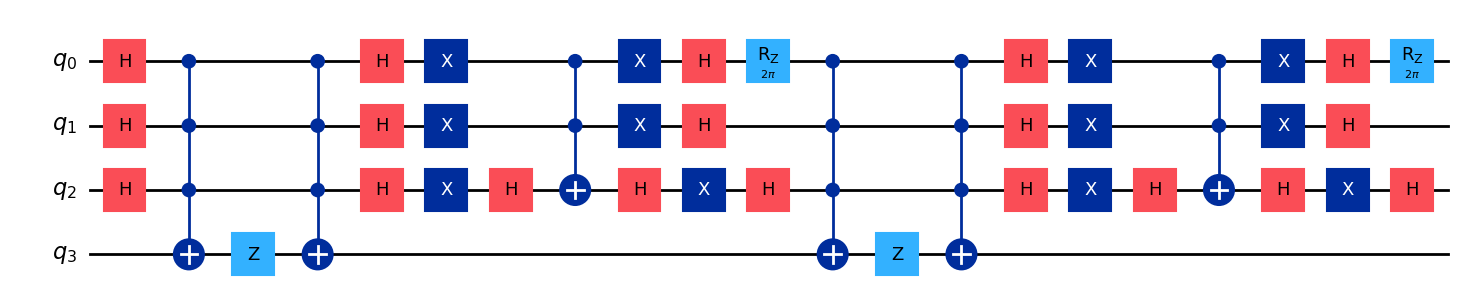

In [8]:
num_data_qubits = 3
num_steps = 2

quantum_circuit = grover_ancilla(num_data_qubits, num_steps)
quantum_circuit.draw("mpl")

Test if your implementation delivers the expected result:

In [9]:
num_data_qubits = 3
num_steps = 2

quantum_circuit = grover_ancilla(num_data_qubits, num_steps)
print_grover_states(quantum_circuit, num_data_qubits)

Found basis states with non-zero amplitudes:
000 0: -0.09  Probability:  0.01
001 0: -0.09  Probability:  0.01
010 0: -0.09  Probability:  0.01
011 0: -0.09  Probability:  0.01
100 0: -0.09  Probability:  0.01
101 0: -0.09  Probability:  0.01
110 0: -0.09  Probability:  0.01
111 0:  0.97  Probability:  0.95


**Exercise 1.3:** Find the appropriate number of Grover steps for 4 and 5 data qubits to maximize the probability for the searched state.

In [10]:
num_data_qubits = 4
num_steps = 3
quantum_circuit = grover_ancilla(num_data_qubits, num_steps)
print_grover_states(quantum_circuit, num_data_qubits)

Found basis states with non-zero amplitudes:
0000 0: -0.05  Probability:  0.00
0001 0: -0.05  Probability:  0.00
0010 0: -0.05  Probability:  0.00
0011 0: -0.05  Probability:  0.00
0100 0: -0.05  Probability:  0.00
0101 0: -0.05  Probability:  0.00
0110 0: -0.05  Probability:  0.00
0111 0: -0.05  Probability:  0.00
1000 0: -0.05  Probability:  0.00
1001 0: -0.05  Probability:  0.00
1010 0: -0.05  Probability:  0.00
1011 0: -0.05  Probability:  0.00
1100 0: -0.05  Probability:  0.00
1101 0: -0.05  Probability:  0.00
1110 0: -0.05  Probability:  0.00
1111 0:  0.98  Probability:  0.96


In [11]:
num_data_qubits = 5
num_steps = 4
quantum_circuit = grover_ancilla(num_data_qubits, num_steps)
print_grover_states(quantum_circuit, num_data_qubits)

Found basis states with non-zero amplitudes:
00000 0: -0.01  Probability:  0.00
00001 0: -0.01  Probability:  0.00
00010 0: -0.01  Probability:  0.00
00011 0: -0.01  Probability:  0.00
00100 0: -0.01  Probability:  0.00
00101 0: -0.01  Probability:  0.00
00110 0: -0.01  Probability:  0.00
00111 0: -0.01  Probability:  0.00
01000 0: -0.01  Probability:  0.00
01001 0: -0.01  Probability:  0.00
01010 0: -0.01  Probability:  0.00
01011 0: -0.01  Probability:  0.00
01100 0: -0.01  Probability:  0.00
01101 0: -0.01  Probability:  0.00
01110 0: -0.01  Probability:  0.00
01111 0: -0.01  Probability:  0.00
10000 0: -0.01  Probability:  0.00
10001 0: -0.01  Probability:  0.00
10010 0: -0.01  Probability:  0.00
10011 0: -0.01  Probability:  0.00
10100 0: -0.01  Probability:  0.00
10101 0: -0.01  Probability:  0.00
10110 0: -0.01  Probability:  0.00
10111 0: -0.01  Probability:  0.00
11000 0: -0.01  Probability:  0.00
11001 0: -0.01  Probability:  0.00
11010 0: -0.01  Probability:  0.00
11011 0: -

## Exercise 2: Optional Registration with IBM Quantum

Go to <https://quantum.cloud.ibm.com/signin> and click on **"Create an IBM Cloud account"** in the top left.

Follow the steps to create an account for the IBM Cloud.

If you accidentally land on the general IBM Cloud instead of the IBM Quantum Cloud during the registration process, simply visit <https://quantum.cloud.ibm.com/> again to return to the Quantum platform.

Once you are logged into the IBM Quantum Cloud, click on **"API key"** in the top left and then on **"Create"**.
Enter a name for the API key and confirm with **Create**.

Then click on **Copy** and save the API key in a secure location — we will need it later in this notebook.

If registration does not work or you do not wish to register, please contact me.
I can provide you with an API key for this lab session.

## Exercise 3: Establishing Connection to IBM Quantum

If you now have an API key at hand, we can establish a connection to the IBM Quantum Cloud and display the available quantum computers.
Afterwards, we will examine the different available backends.

**Exercise 3.1:** Establishing Connection to IBM Quantum Cloud

To establish a connection to the IBM Quantum Cloud, we use the `QiskitRuntimeService` function.
We need to pass our API key to this function to enable authentication and access to available resources.
The function returns an object through which the hardware backends can subsequently be accessed.

Insert your API key into the following code and display all available backends.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Connect to IBM Quantum Cloud
service = QiskitRuntimeService(channel="ibm_cloud", token="INSERT TOKEN HERE")
service.backends()

qiskit_runtime_service._discover_account:WARNING:2026-04-15 12:09:12,067: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-04-15 12:09:14,927: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-15 12:09:14,929: Loading instance: open-instance, plan: open


[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_kingston')>]

**Exercise 3.2:** Using a Specific Quantum Backend

To use a specific quantum backend, a backend object can be created using the `service.backend()` function.
The name of the desired backend must be passed. Example:

```python
backend_fez = service.backend('ibm_fez')
```

Subsequently, investigate:

* The number of qubits of the backend (accessible via ``backend.num_qubits``)
* The quantum gates available on the hardware (accessible via ``backend.operation_names``)

Compare the quantum gates required for your implementation of the Grover algorithm with the gates available on the hardware.

In [13]:
# Initialization of the real backend ibm_fez and output of qubits and native gates
backend_fez = service.backend("ibm_fez")
print("Number of Qubits:", backend_fez.num_qubits)
print("Quantum Gates:", backend_fez.operation_names)

qiskit_runtime_service.backends:WARNING:2026-04-15 12:09:15,723: Using instance: open-instance, plan: open


Number of Qubits: 156
Quantum Gates: ['x', 'cz', 'id', 'delay', 'sx', 'rz', 'reset', 'if_else', 'measure']


**Observation:** The native quantum gates are different from those in the quantum circuit.

**Exercise 3.3:** To test software access to the hardware, we first use a simulated quantum computer. This possesses the same software interface as the real hardware but consumes no computing time.

In the following code, the backend `FakeManilaV2` is initialized.
Find out the number of qubits and the possible quantum gates here as well.

In [14]:
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

backend_fake_manila = FakeManilaV2()

In [15]:
print(backend_fake_manila.num_qubits)
print(backend_fake_manila.operation_names)

5
['x', 'switch_case', 'id', 'cx', 'delay', 'sx', 'rz', 'reset', 'for_loop', 'if_else', 'measure']


### Exercise 4: Transpiling

We saw in Exercise 3 that a quantum computer only provides a specific set of quantum gates. Some of these gates (e.g., `sx`, i.e., $\sqrt{X}$ – the square root of the X-gate) were not covered in the lecture.

It is important that every quantum computer provides a universal set of quantum gates (universal gateset). This means that *every* quantum gate can be represented as a combination of these native gates.

If we want to execute a circuit on real hardware, we must first translate it into the native gates of the respective quantum computer.
This process is called **Transpiling** and is essential for being able to switch between different gate sets.

Besides converting between different gates, transpilation additionally optimizes the circuit:
- Redundant gates (e.g., $XX = I$) are removed
- Gates are swapped if possible without changing the state
- It is determined on which physical qubits of the hardware the circuit will be executed – taking individual error rates into account

Basically, transpilation in quantum computing is comparable to compilation on a classical computer.

In Qiskit, there is the function `transpile` for this.
It receives a backend and a quantum circuit and returns the transpiled circuit.


In [16]:
from qiskit.compiler import transpile

quantum_circuit1 = QuantumCircuit(1)
backend_manila = FakeManilaV2()

transpiled_circuit = transpile(quantum_circuit1, backend=backend_manila)

**Exercise 4.1:** Transpile the circuit of your Grover implementation for 3 data qubits and one Grover step and compare it with the original circuit.
Perform the transpilation once with the simulated backend (`FakeManilaV2()`) and once with the real IBM backend (`service.backend('ibm_fez')`).

Visualize the quantum gates with the function `quantum_circuit.draw('mpl')` and examine the number of individual quantum gates in the circuits for all three cases.

**Hint:** There is a function for counting quantum gates for quantum circuits:
`quantum_circuit.count_ops()`

OrderedDict([('h', 13), ('x', 6), ('ccx', 2), ('rz', 1)])


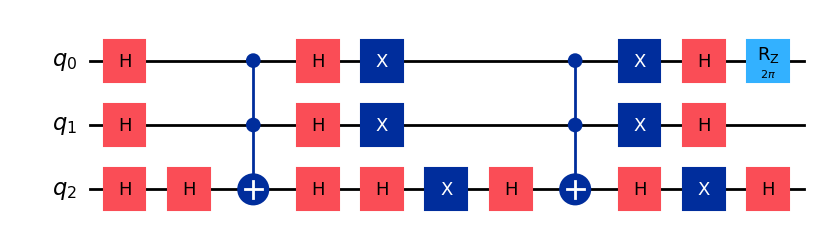

In [17]:
# Original Grover Circuit
num_data_qubits = 3
num_steps = 1
quantum_circuit = grover(num_data_qubits, num_steps)

print(quantum_circuit.count_ops())
quantum_circuit.draw("mpl")

OrderedDict([('rz', 29), ('cx', 19), ('sx', 12), ('x', 1)])


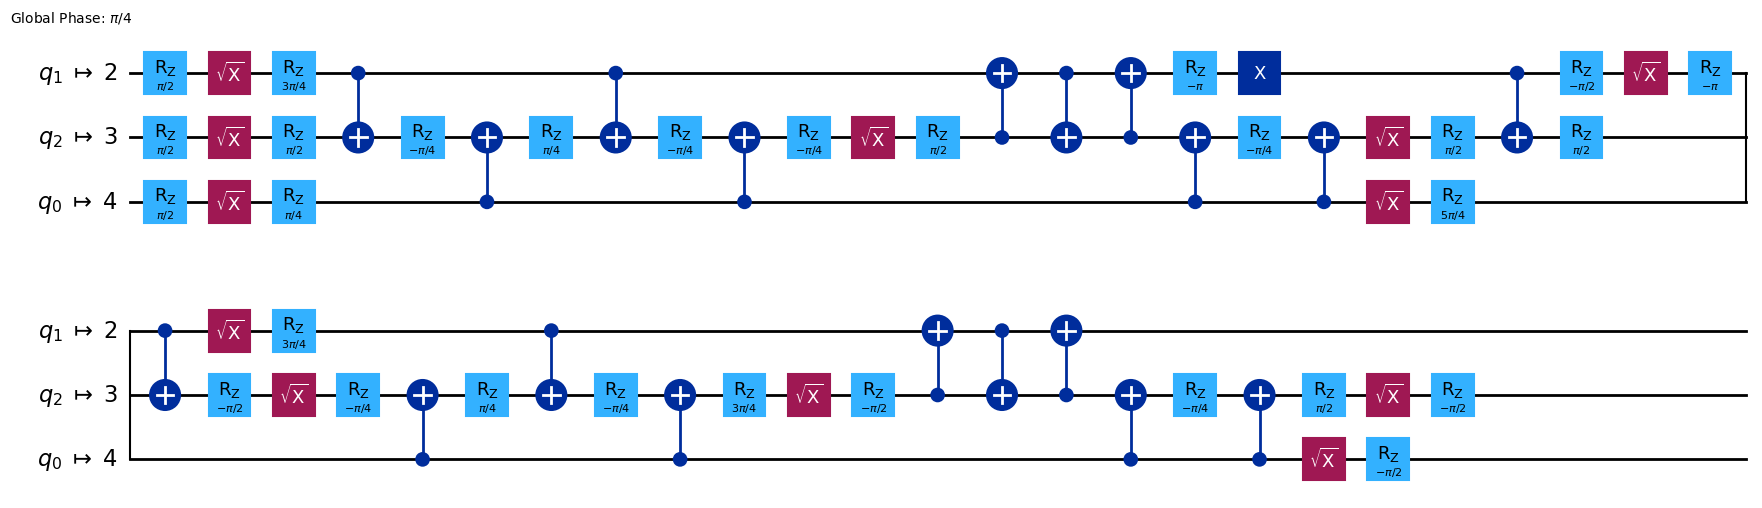

In [18]:
# Transpilation and output for the simulated backend
quantum_circuit_transpiled = transpile(quantum_circuit, backend=backend_fake_manila)
print(quantum_circuit_transpiled.count_ops())
quantum_circuit_transpiled.draw("mpl")

OrderedDict([('sx', 38), ('rz', 34), ('cz', 17)])


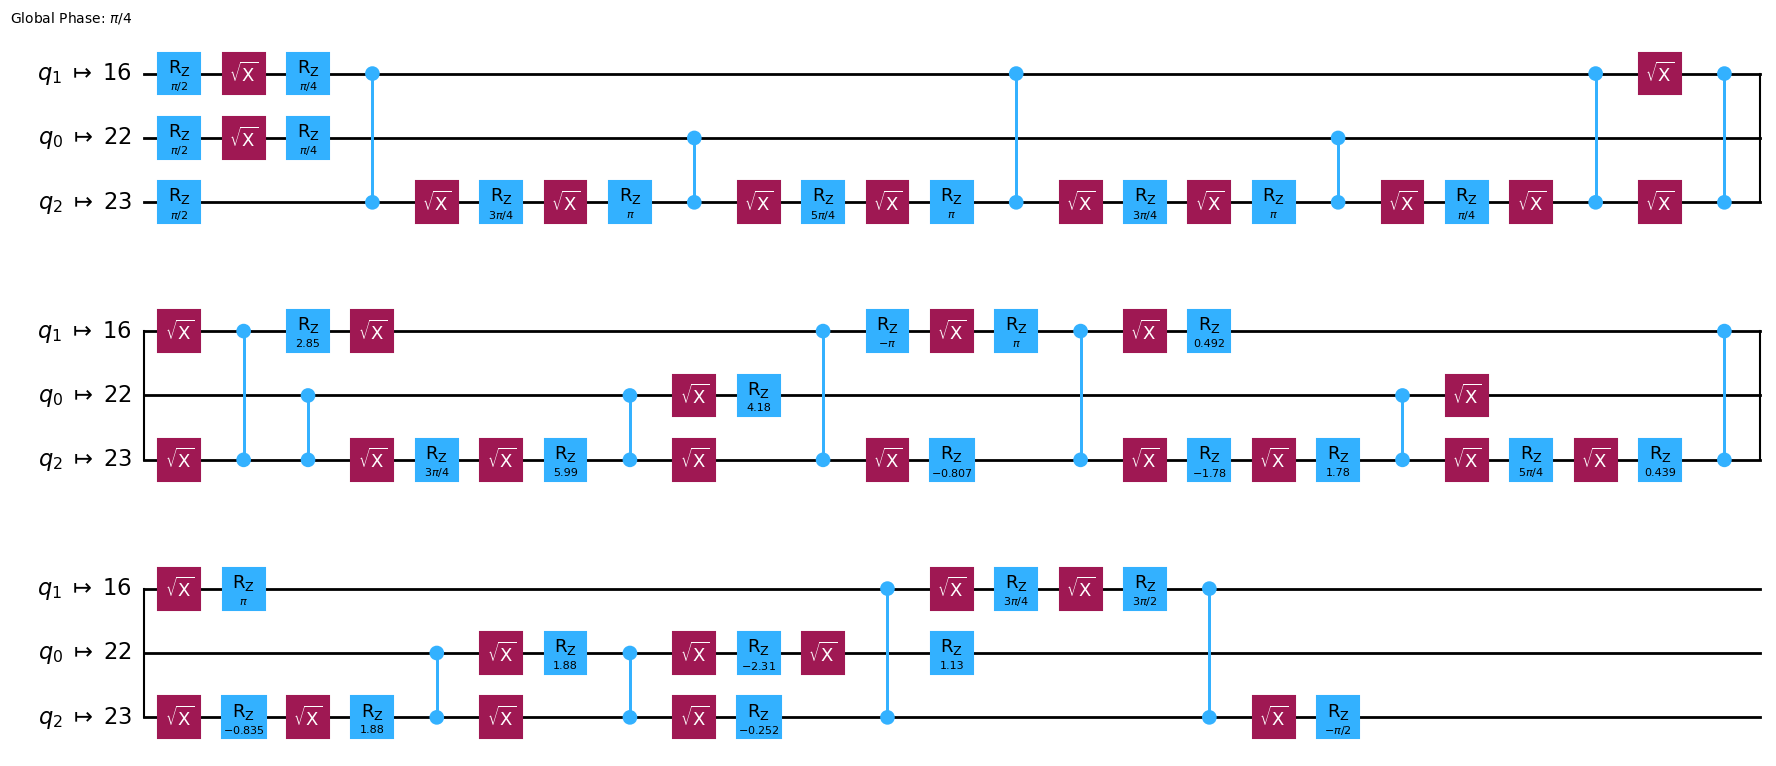

In [19]:
# Transpilation and output for the real backend ibm_fez
quantum_circuit_transpiled = transpile(quantum_circuit, backend=backend_fez)
print(quantum_circuit_transpiled.count_ops())
quantum_circuit_transpiled.draw("mpl")

**Exercise 4.2:** Repeat Exercise 4.1 for the circuit with the additional ancilla qubit (3 data qubits and 1 Grover step).
Then compare the number of 2-qubit gates (`cx` and `cz`) with the case without an ancilla qubit.

OrderedDict([('h', 11), ('x', 6), ('mcx', 2), ('z', 1), ('ccx', 1), ('rz', 1)])


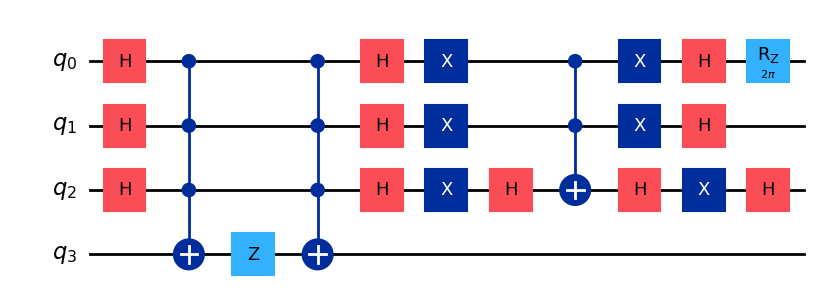

In [20]:
# Original Grover Circuit
num_data_qubits = 3
num_steps = 1
quantum_circuit = grover_ancilla(num_data_qubits, num_steps)
print(quantum_circuit.count_ops())
quantum_circuit.draw("mpl")

OrderedDict([('rz', 86), ('cx', 57), ('sx', 48), ('x', 3)])


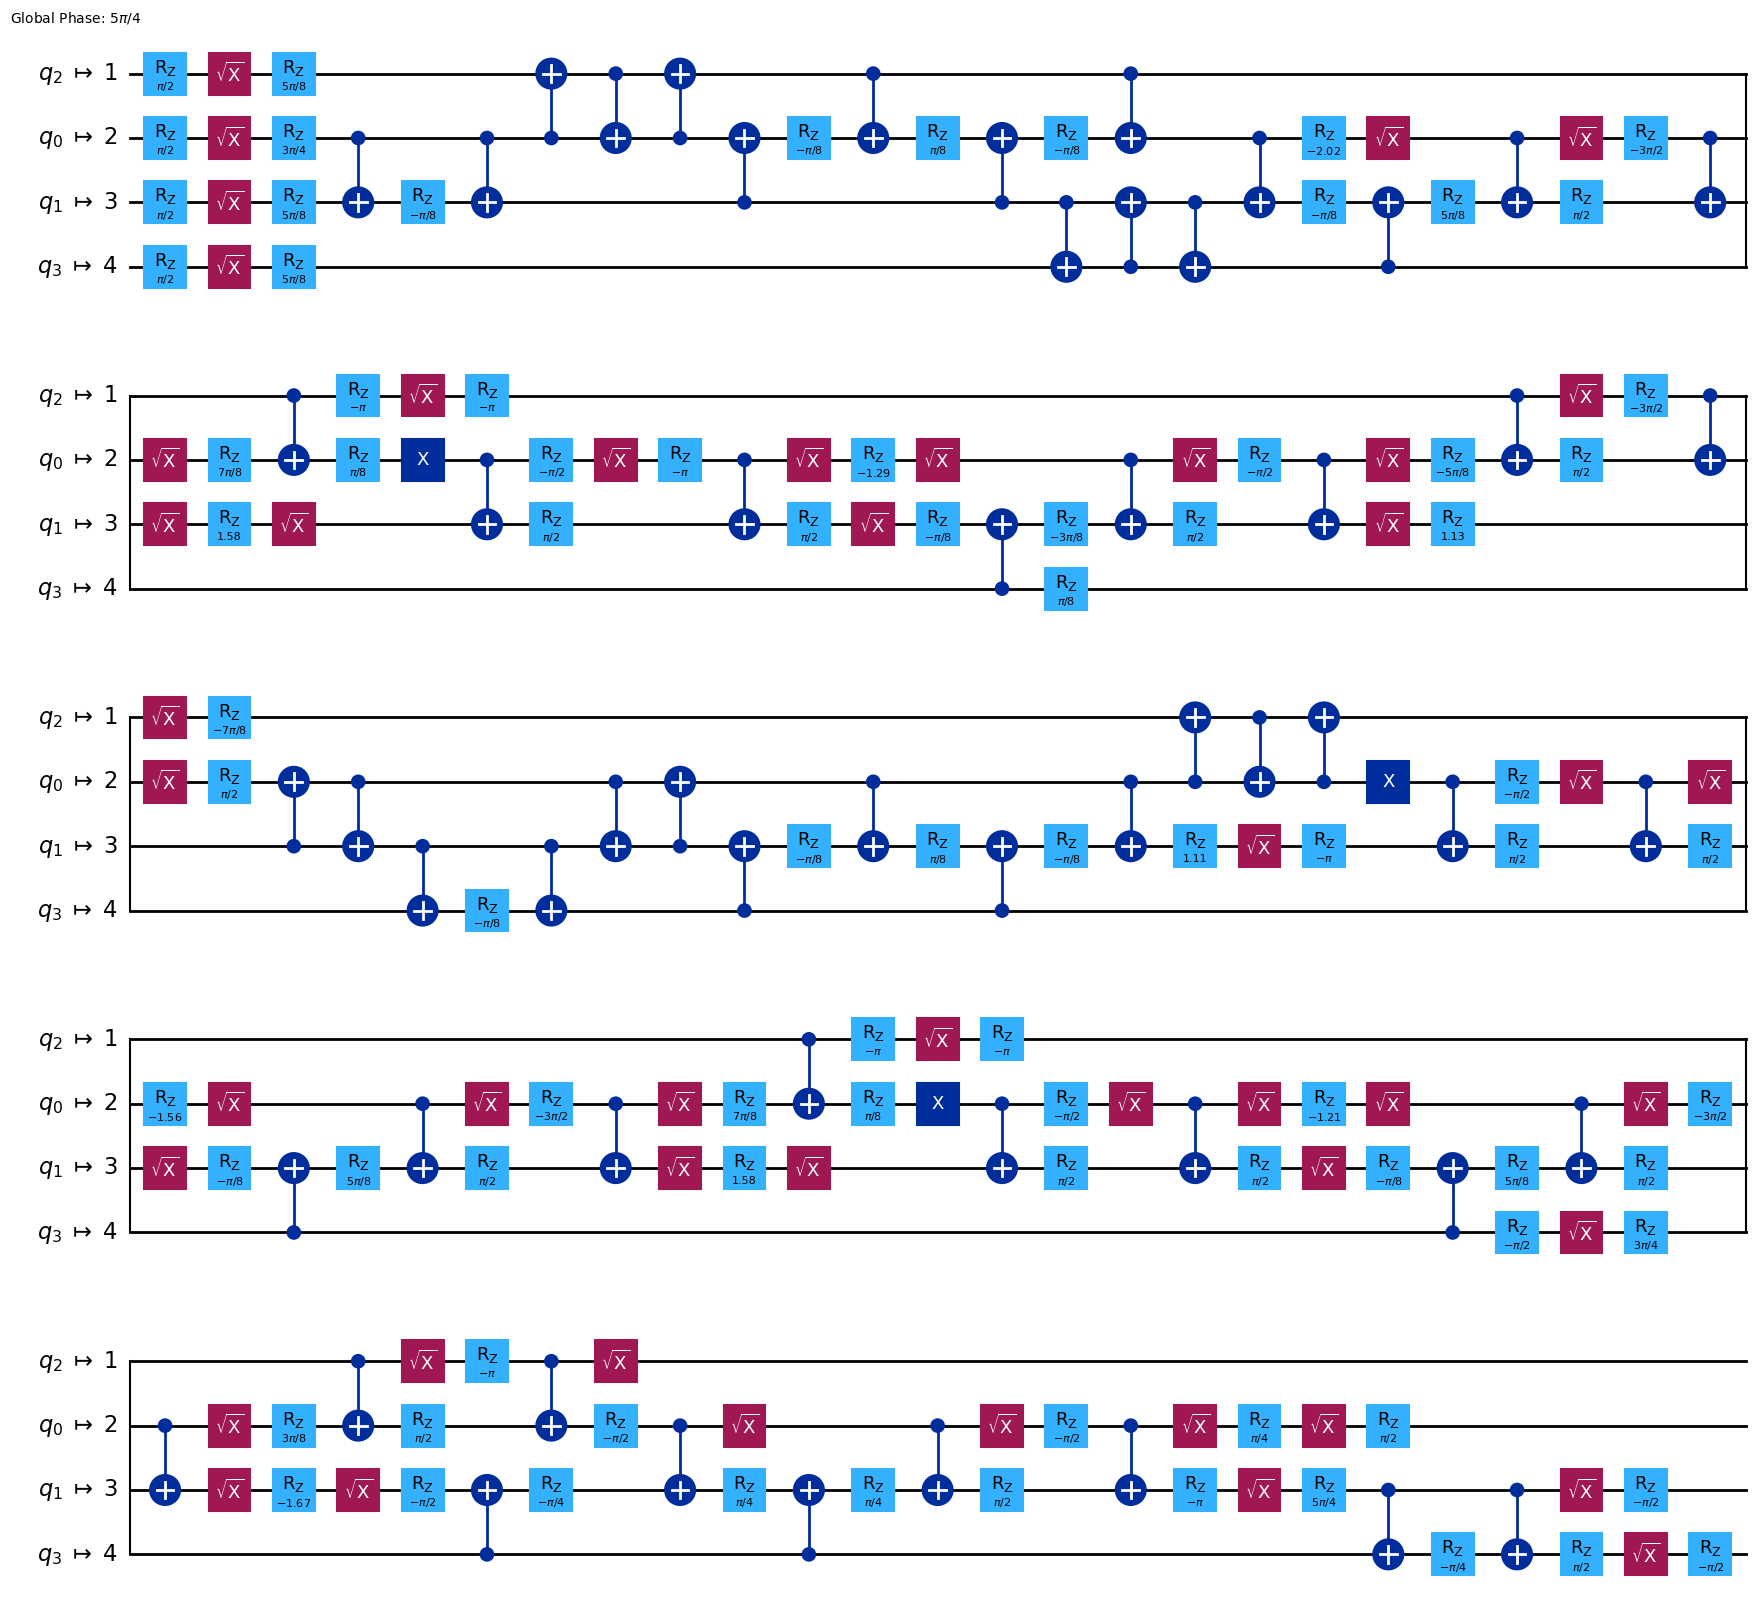

In [21]:
# Transpilation and output for the simulated backend
quantum_circuit_transpiled = transpile(quantum_circuit, backend=backend_fake_manila)
print(quantum_circuit_transpiled.count_ops())
quantum_circuit_transpiled.draw("mpl")

OrderedDict([('sx', 109), ('rz', 79), ('cz', 47), ('x', 2)])


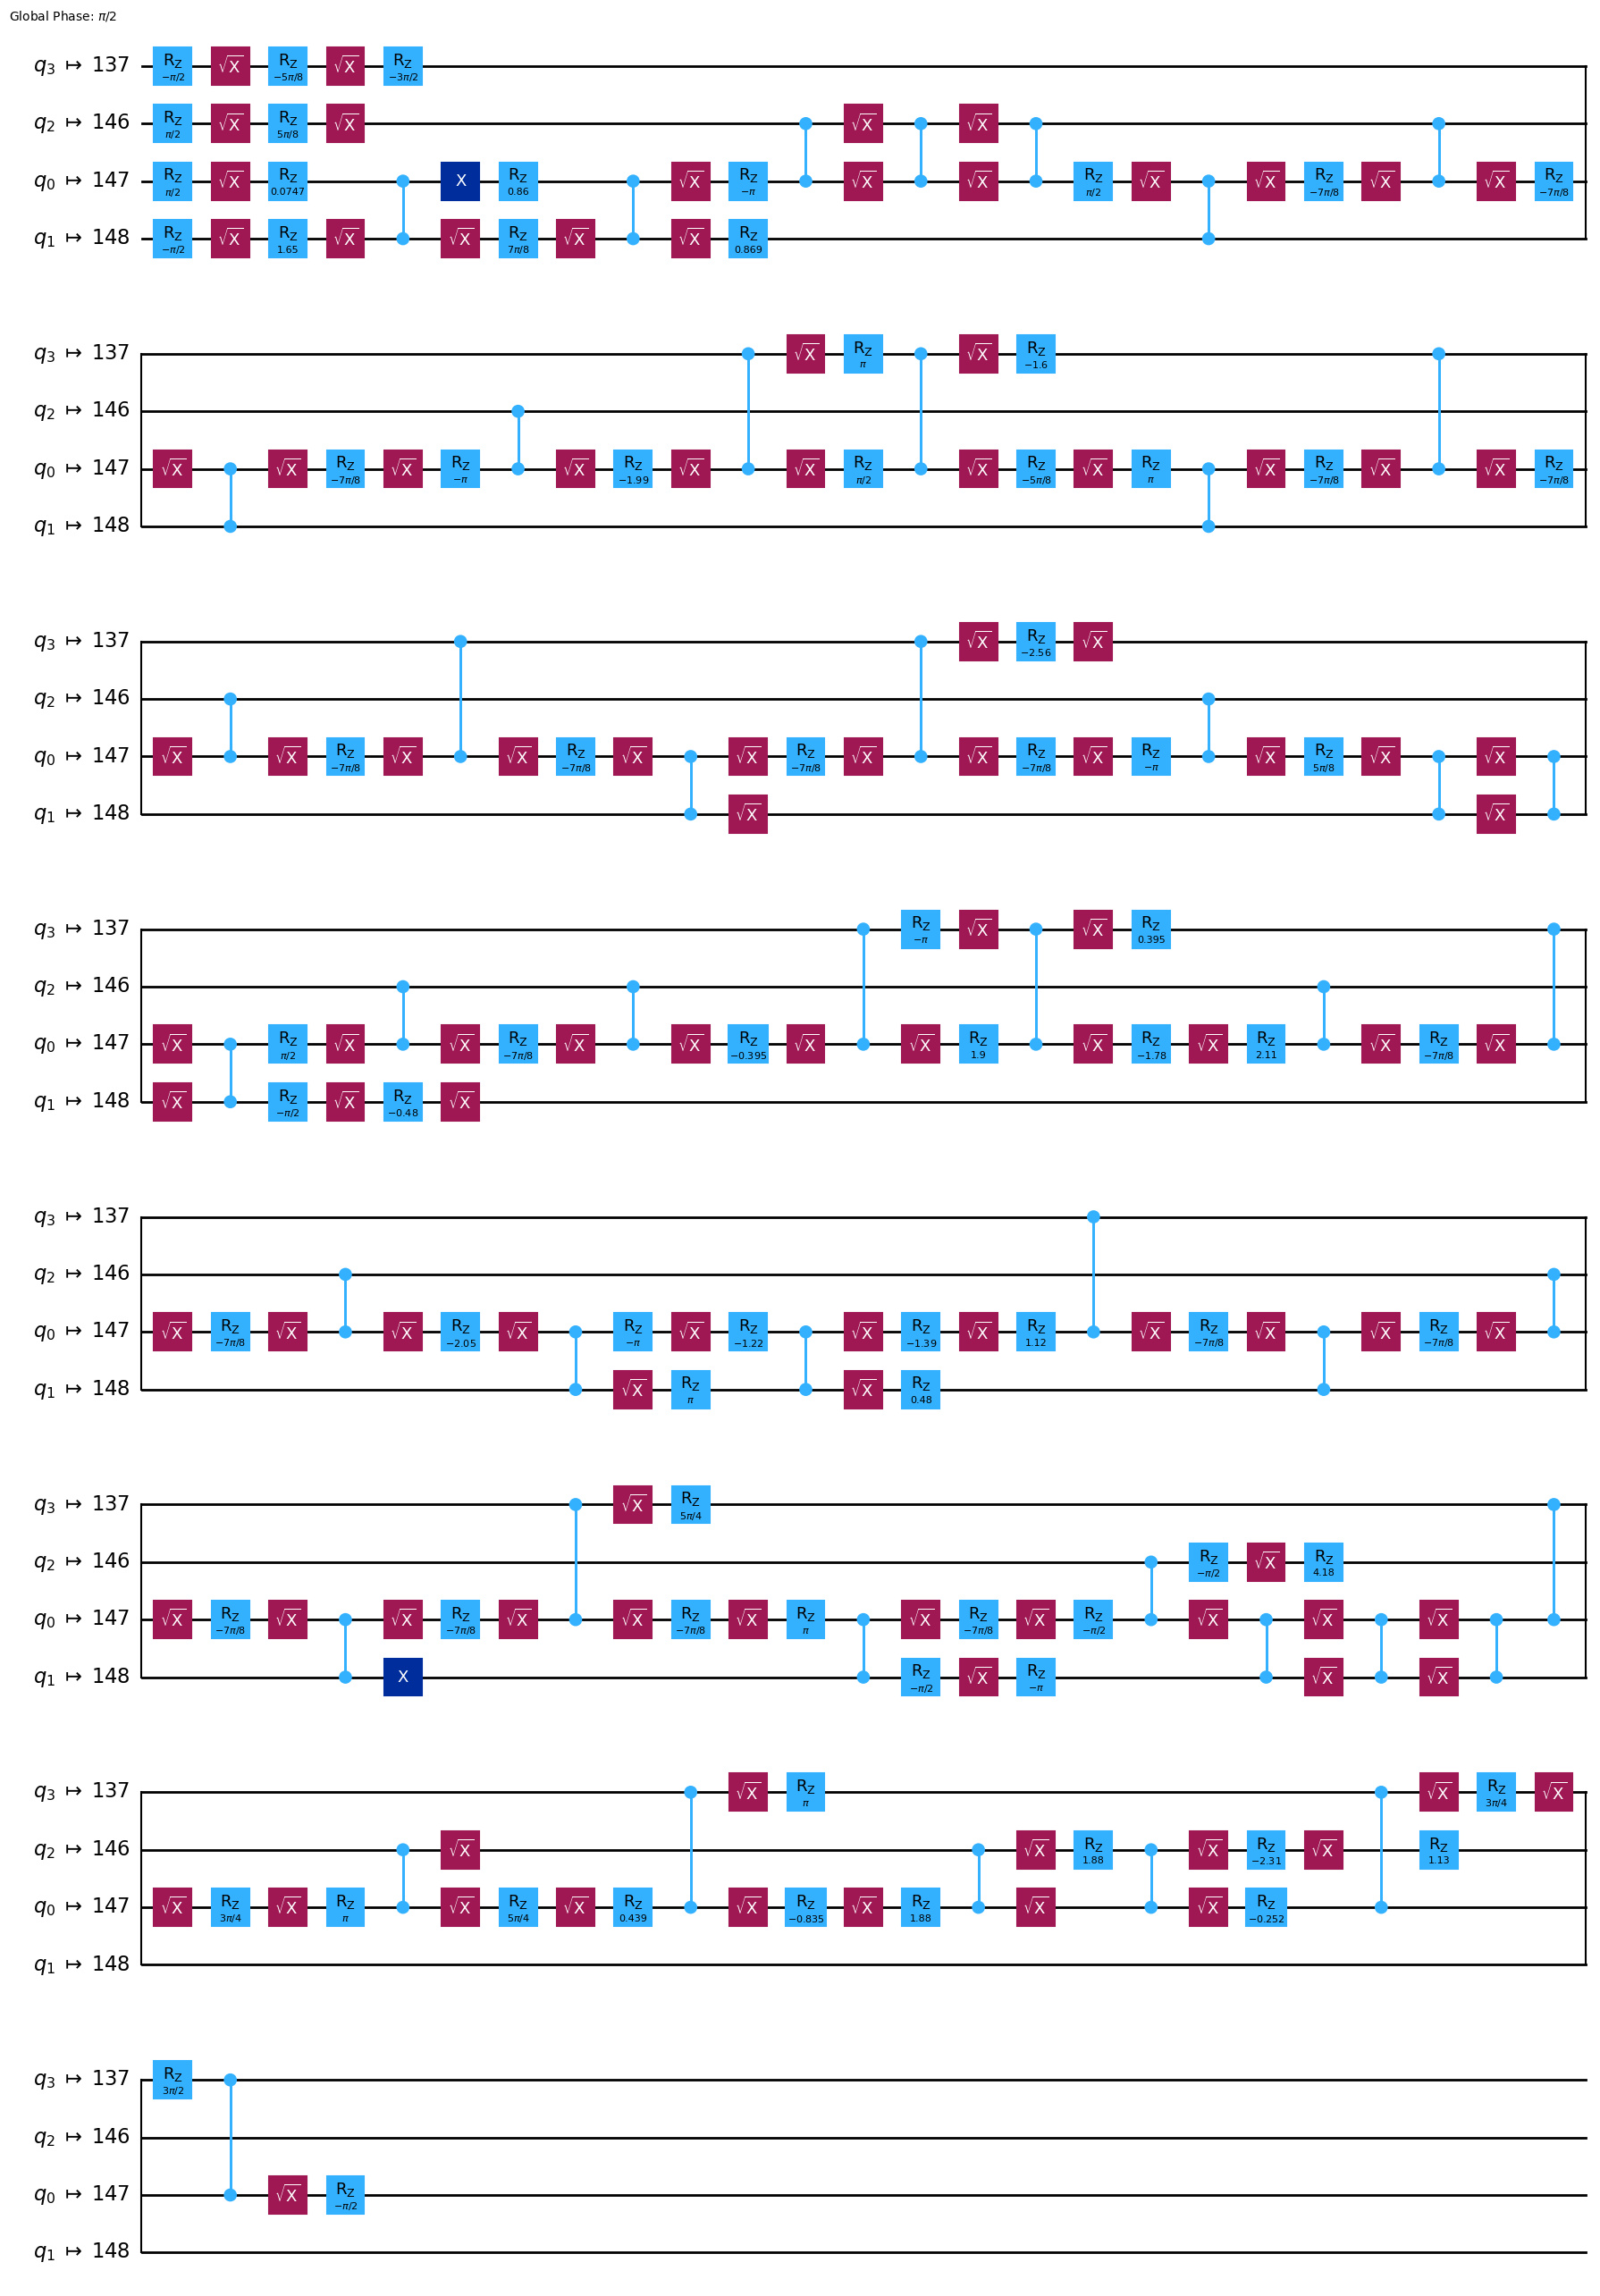

In [22]:
# Transpilation and output for the real backend ibm_fez
quantum_circuit_transpiled = transpile(quantum_circuit, backend=backend_fez)
print(quantum_circuit_transpiled.count_ops())
quantum_circuit_transpiled.draw("mpl")

### Exercise 5: Executing with Simulated Hardware

Now all intermediate steps are in place to execute the Grover circuits on real hardware later.
In this section, we no longer use our own helper functions, but use Qiskit directly for the execution and sampling of the quantum circuits.

For practice, we first run all experiments with a simulator to ensure everything works as expected.
You do not have to implement much yourself here, but can reuse and adapt the given code multiple times.

**Attention:** In Qiskit, the numbering of bits in the basis states is different than before.
The first qubit is on the **right** in the bitstring: $\ket{q_n \ldots q_3 q_2 q_1}$.

To match our previous numbering again, we can call the function `quantum_circuit.reverse_bits()` before measurement to reverse the order of the qubits.

The following code implements sampling the circuit for the Bell State on the quantum hardware and returns the result as a Python dictionary.

To test your access, you can also replace the simulated backend with a real IBM backend.

In [23]:
# Example code for measuring the Bell State on quantum hardware

from qiskit_ibm_runtime import SamplerV2

# Bell State
quantum_circuit = QuantumCircuit(2)
quantum_circuit.h(0)
quantum_circuit.cx(0, 1)

# Reverse the order of qubits:
quantum_circuit = quantum_circuit.reverse_bits()

# Add final measurement
quantum_circuit.measure_all()

# Transpilation of the circuit
quantum_circuit_transpiled = transpile(quantum_circuit, backend=backend_fake_manila)

# Number of measurements
num_shots = 100

# Initialization of the Sampler Primitive in Qiskit to execute measurements on the hardware.
# mode= sets the backend.
sampler = SamplerV2(mode=backend_fake_manila, options={"default_shots": num_shots})

# In Qiskit, circuits are passed in a list to support executing multiple circuits
# at once. Here we simply take a list of one circuit.
pubs = [quantum_circuit_transpiled]

# With this call, we send our circuit (our circuits) to Qiskit.
# The circuits are queued by IBM until they are executed.
job = sampler.run(pubs)

# The function job.result() waits until the result is available.
# Since we have to pass the circuit as a list, we also get the result as a list.
# We take the first element of the list to get to our result.
result = job.result()[0]

# To get the number of measurements, we use the following function:
result.data.meas.get_counts()

{'00': 49, '11': 45, '10': 2, '01': 4}

You can now reuse the code from above and only adapt the backend and the quantum circuit in each case.

**Exercise 5.1:** First test your Grover implementation without ancilla qubits for 3 data qubits and 2 Grover steps with the simulator.

In [24]:
num_data_qubits = 3
num_steps = 2
quantum_circuit = grover(num_data_qubits, num_steps)
quantum_circuit = quantum_circuit.reverse_bits()
quantum_circuit.measure_all()
quantum_circuit_transpiled = transpile(quantum_circuit, backend=backend_fake_manila)

num_shots = 100
sampler = SamplerV2(mode=backend_fake_manila, options={"default_shots": num_shots})

pubs = [quantum_circuit_transpiled]
job = sampler.run(pubs)
result = job.result()[0]

result.data.meas.get_counts()

{'010': 7, '001': 4, '111': 63, '011': 4, '110': 14, '101': 5, '000': 3}

**Exercise 5.2:** Repeat Exercise 5.1 for your Grover implementation **with ancilla qubit** for 3 data qubits and 2 Grover steps on the simulator.
What do you observe compared to the implementation without an ancilla qubit?

In [25]:
num_data_qubits = 3
num_steps = 2
quantum_circuit = grover_ancilla(num_data_qubits, num_steps)
quantum_circuit = quantum_circuit.reverse_bits()
quantum_circuit.measure_all()
quantum_circuit_transpiled = transpile(quantum_circuit, backend=backend_fake_manila)

num_shots = 100
sampler = SamplerV2(mode=backend_fake_manila, options={"default_shots": num_shots})

pubs = [quantum_circuit_transpiled]
job = sampler.run(pubs)
result = job.result()[0]

result.data.meas.get_counts()

{'1110': 29,
 '1100': 10,
 '0111': 5,
 '1000': 5,
 '0010': 7,
 '0001': 5,
 '1111': 7,
 '0100': 2,
 '1010': 5,
 '0000': 4,
 '0011': 3,
 '1011': 3,
 '0110': 5,
 '1101': 4,
 '0101': 3,
 '1001': 3}

**Exercise 5.3:** Investigate whether you still get good results with the simulator and **without** an ancilla qubit for 4 data qubits and 2 Grover steps.

In [26]:
num_data_qubits = 4
num_steps = 2
quantum_circuit = grover(num_data_qubits, num_steps)
quantum_circuit = quantum_circuit.reverse_bits()
quantum_circuit.measure_all()
quantum_circuit_transpiled = transpile(quantum_circuit, backend=backend_fake_manila)

num_shots = 100
sampler = SamplerV2(mode=backend_fake_manila, options={"default_shots": num_shots})

pubs = [quantum_circuit_transpiled]
job = sampler.run(pubs)
result = job.result()[0]

result.data.meas.get_counts()

{'1001': 7,
 '1111': 32,
 '0010': 4,
 '1101': 10,
 '0111': 8,
 '0110': 6,
 '1100': 3,
 '0101': 1,
 '1011': 7,
 '0001': 4,
 '1000': 5,
 '0011': 3,
 '0100': 5,
 '1110': 2,
 '0000': 1,
 '1010': 2}

**Exercise 5.4:** What does the result look like for the Grover algorithm **with ancilla qubit** for 4 data qubits and 2 Grover steps?

In [27]:
num_data_qubits = 4
num_steps = 2
quantum_circuit = grover_ancilla(num_data_qubits, num_steps)
quantum_circuit = quantum_circuit.reverse_bits()
quantum_circuit.measure_all()
quantum_circuit_transpiled = transpile(quantum_circuit, backend=backend_fake_manila)

num_shots = 100
sampler = SamplerV2(mode=backend_fake_manila, options={"default_shots": num_shots})

pubs = [quantum_circuit_transpiled]
job = sampler.run(pubs)
result = job.result()[0]

result.data.meas.get_counts()

{'01111': 3,
 '01010': 3,
 '11111': 3,
 '00100': 6,
 '00011': 6,
 '10101': 4,
 '10000': 9,
 '11101': 3,
 '10001': 5,
 '11010': 2,
 '10010': 3,
 '10100': 3,
 '00110': 7,
 '00010': 3,
 '10111': 2,
 '01001': 4,
 '11100': 2,
 '11001': 2,
 '11110': 2,
 '01110': 2,
 '11000': 2,
 '01000': 1,
 '10011': 2,
 '00001': 2,
 '01101': 2,
 '01011': 1,
 '01100': 4,
 '11011': 3,
 '00111': 1,
 '00000': 4,
 '00101': 2,
 '10110': 2}

### Exercise 6: Execution on Real Quantum Hardware

Now that the Grover algorithm works on the simulator, we can repeat the calculations on the real hardware.
Simply copy the code from above and swap only the backend during the initialization of the sampler.

**Exercise 6.1:** Run your Grover implementation **without ancilla qubit** with 3 data qubits and 2 Grover steps on the real quantum hardware.

In [28]:
num_data_qubits = 3
num_steps = 2
quantum_circuit = grover(num_data_qubits, num_steps)
quantum_circuit = quantum_circuit.reverse_bits()
quantum_circuit.measure_all()
quantum_circuit_transpiled = transpile(quantum_circuit, backend=backend_fez)

num_shots = 100
sampler = SamplerV2(mode=backend_fez, options={"default_shots": num_shots})

pubs = [quantum_circuit_transpiled]
job = sampler.run(pubs)
result = job.result()[0]

result.data.meas.get_counts()

{'111': 68, '110': 8, '001': 4, '101': 9, '011': 3, '000': 4, '010': 4}

**Exercise 6.2:** Repeat the whole thing for 4 data qubits with 3 Grover steps and for 5 data qubits with 4 Grover steps.
What do you observe?

In [29]:
num_data_qubits = 4
num_steps = 3
quantum_circuit = grover(num_data_qubits, num_steps)
quantum_circuit = quantum_circuit.reverse_bits()
quantum_circuit.measure_all()
quantum_circuit_transpiled = transpile(quantum_circuit, backend=backend_fez)

num_shots = 100
sampler = SamplerV2(mode=backend_fez, options={"default_shots": num_shots})

pubs = [quantum_circuit_transpiled]
job = sampler.run(pubs)
result = job.result()[0]

result.data.meas.get_counts()

{'1110': 4,
 '1111': 46,
 '1100': 4,
 '0111': 6,
 '1001': 6,
 '0010': 5,
 '0001': 3,
 '0100': 3,
 '0011': 4,
 '0110': 1,
 '1000': 2,
 '0000': 6,
 '0101': 1,
 '1011': 5,
 '1010': 2,
 '1101': 2}

In [30]:
num_data_qubits = 5
num_steps = 4
quantum_circuit = grover(num_data_qubits, num_steps)
quantum_circuit = quantum_circuit.reverse_bits()
quantum_circuit.measure_all()
quantum_circuit_transpiled = transpile(quantum_circuit, backend=backend_fez)

num_shots = 100
sampler = SamplerV2(mode=backend_fez, options={"default_shots": num_shots})

sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XX"

pubs = [quantum_circuit_transpiled]
job = sampler.run(pubs)
result = job.result()[0]

result.data.meas.get_counts()

{'10100': 4,
 '11000': 4,
 '10011': 1,
 '01111': 3,
 '00001': 2,
 '10000': 2,
 '10010': 3,
 '11111': 14,
 '11001': 5,
 '01101': 2,
 '10111': 5,
 '01010': 4,
 '11101': 3,
 '01100': 3,
 '11100': 5,
 '00110': 3,
 '01011': 5,
 '11011': 4,
 '10001': 2,
 '00011': 3,
 '10110': 5,
 '10101': 1,
 '01110': 4,
 '11110': 3,
 '01001': 4,
 '01000': 2,
 '00000': 3,
 '00100': 1}

In [31]:
num_data_qubits = 6
num_steps = 4
quantum_circuit = grover(num_data_qubits, num_steps)
quantum_circuit = quantum_circuit.reverse_bits()
quantum_circuit.measure_all()
quantum_circuit_transpiled = transpile(quantum_circuit, backend=backend_fez)

print(quantum_circuit_transpiled.count_ops())

num_shots = 100
sampler = SamplerV2(mode=backend_fez, options={"default_shots": num_shots})

pubs = [quantum_circuit_transpiled]
job = sampler.run(pubs)
result = job.result()[0]

result.data.meas.get_counts()

OrderedDict([('sx', 2715), ('rz', 1863), ('cz', 1265), ('x', 41), ('measure', 6), ('barrier', 1)])


{'111010': 2,
 '100110': 4,
 '111101': 3,
 '110110': 5,
 '101011': 1,
 '001001': 1,
 '110000': 2,
 '000100': 2,
 '011100': 1,
 '000111': 2,
 '010111': 3,
 '010001': 2,
 '010000': 4,
 '010010': 3,
 '000010': 4,
 '110101': 2,
 '111000': 3,
 '011001': 4,
 '010101': 2,
 '101100': 3,
 '110001': 1,
 '111011': 2,
 '100011': 1,
 '010011': 2,
 '010110': 1,
 '001000': 3,
 '101001': 2,
 '101010': 1,
 '110010': 2,
 '100001': 2,
 '010100': 1,
 '011110': 3,
 '011111': 2,
 '001010': 2,
 '101101': 1,
 '111001': 1,
 '110011': 1,
 '000000': 1,
 '011010': 2,
 '000110': 1,
 '100000': 1,
 '110100': 1,
 '011101': 3,
 '100101': 2,
 '000011': 1,
 '110111': 2,
 '111110': 1,
 '101111': 2,
 '111111': 1,
 '011011': 1}

**Exercise 6.3:** Now run the Grover variant **with ancilla qubit** for 4 data qubits and 3 Grover steps on the hardware.

In [32]:
num_data_qubits = 4
num_steps = 3
quantum_circuit = grover_ancilla(num_data_qubits, num_steps)
quantum_circuit = quantum_circuit.reverse_bits()
quantum_circuit.measure_all()
quantum_circuit_transpiled = transpile(quantum_circuit, backend=backend_fez)

num_shots = 100
sampler = SamplerV2(mode=backend_fez, options={"default_shots": num_shots})

pubs = [quantum_circuit_transpiled]
job = sampler.run(pubs)
result = job.result()[0]

result.data.meas.get_counts()

{'01001': 1,
 '00111': 2,
 '11100': 4,
 '11111': 3,
 '10101': 3,
 '00000': 7,
 '10100': 4,
 '01111': 4,
 '10010': 4,
 '01110': 5,
 '00110': 5,
 '00001': 5,
 '11001': 5,
 '01010': 3,
 '10001': 2,
 '01100': 2,
 '11110': 6,
 '11011': 4,
 '11010': 2,
 '01011': 4,
 '00101': 4,
 '00010': 2,
 '10111': 1,
 '00100': 3,
 '10000': 5,
 '11000': 1,
 '10011': 3,
 '00011': 2,
 '01101': 1,
 '10110': 1,
 '11101': 2}